#  Impact of AOCS jitter on the photometry at camera level

$\textbf{Goals}$

Test the impact and behavior of spacecraft Attitude and Orbital Control System (AOCS) jitter on camera level. 

$\textbf{Context}$

In order to achieve the required noise budget at mission level, the PMC has defined Mean Pointing Error and Relative Pointing Error requirements at camera level. In the high frequency range ($f \gg 0.04$Hz), the dominant contribution results from the performance of the attitude and orbit control system of the S/C (jitter).

$\textbf{Simulations}$

To test the impact of jitter it should be enough to have several short-term simulations (1 day long), for 24 N-CAMs and several quarters. Specifically one simulation with fast jitter (8 Hz), and one simulation without jitter (only white noise jitter) shall be compared to tell whether a jitter correction on-ground is mandatory or not. 
Prime have delivered a high frequency jitter simulations for one N-Cam w.r.t. to F2-Cam with a cadence of 8 Hz and duration of 27h. We shall investigate if this simulation can be cycled to the remaining cameras and how this might impact the forthcoming analysis.

As a baseline, we keep on-ground processing as an option for WC of the impact of jitter.

$\textbf{Data analysis}$

### Setup notebook

In [1067]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib inline
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [1068]:
import os
import sys
import h5py
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import periodogram
from scipy.ndimage import median_filter
from zipfile import ZipFile

# PlatoSim
import platosim.plot as pt
import platosim.utilities as ut
import platosim.referenceFrames as rf
from platosim.photometryfile import PhotometryFile
from platosim.matplotlibrc   import setup
setup()

### Functions

In [1069]:
def matrixMisalignment(x, y, z):   
    r11 = + np.cos(x)*np.cos(z) - np.sin(x)*np.sin(z)*np.sin(y)
    r12 = - np.cos(x)*np.sin(z) - np.sin(x)*np.cos(z)*np.cos(y)
    r13 = + np.sin(x)*np.sin(z)
    r21 = + np.sin(x)*np.cos(z) + np.cos(x)*np.sin(z)*np.cos(y)
    r22 = - np.sin(x)*np.sin(z) - np.cos(x)*np.cos(z)*np.cos(y)
    r23 = - np.cos(x)*np.sin(z)
    r31 = + np.sin(z)*np.sin(y)
    r32 = + np.cos(z)*np.sin(y)
    r33 = - np.cos(y)   
    R = np.array([[r11, r12, r13],
                  [r21, r22, r23],
                  [r31, r32, r33]])
    return R


def changeOfPointing(x, y, z, phi, theta):
    R = np.array([[ 0, -z,  y],
                  [ z,  0, -x],
                  [-y,  x,  0]])
    A = np.array([[np.cos(phi)*np.sin(theta)],
                  [np.sin(phi)*np.sin(theta)], 
                  [1]])
    return np.dot(R,A).T

---
## 1) Pointing errors 
---

The Prime is delivering the coefficients of the rotations matrices transforming the pointing directions in the
PLM (payload module) reference frame, so-called **Quatrions**.

---
### 1.1) Prime 2021-09-20: AOCS + TED in CM LOS
---
Each LOS variable has a sample rate of 8Hz and is in radians. The periods where reaction wheel offloading were simulated, including a tranquilisation time after the transition from OLM back to GAM are set to `NaN`.

In [1127]:
# Load Prime 
path  = "/lhome/nicholas/Nextcloud/Platoman/Models/Jitter/Prime2021sep"
f = h5py.File(f"{path}/CM_LOS_Combined_v2.mat", "r")
xLOS = f['LOSX'][0]
yLOS = f['LOSY'][0]
zLOS = f['LOSZ'][0]

In [1128]:
# Shorten time series and create time points
tdur       = 27       # [h]
dt         = 0.125    # [s] 8 Hz
rad2arcsec = 206265   # Conversion

# Use on tdur lenght of dataset
l = int(tdur * 3600 / dt)
t = np.arange(0, len(xLOS), dt)[:l]
x = xLOS[:l] * rad2arcsec 
y = yLOS[:l] * rad2arcsec
z = zLOS[:l] * rad2arcsec

In [1129]:
# Remove NaNs
t = t[~np.isnan(x)]
x = x[~np.isnan(x)]
y = y[~np.isnan(y)]
z = z[~np.isnan(z)]

# Relative pointing
x -= np.mean(x)
y -= np.mean(y)
z -= np.mean(z)

# Columns for plotting and saving
signals = np.array([x, y, z]).T
data = np.array([t, x, y, z]).T

In [1130]:
# Save jitter file
np.savetxt(f'{os.getcwd()}/AOCS_Prime_2021sep_27h_8Hz.txt', data, delimiter=' ',
          fmt=['%.3f', '%.9f', '%.9f', '%.9f'])

<IPython.core.display.Javascript object>


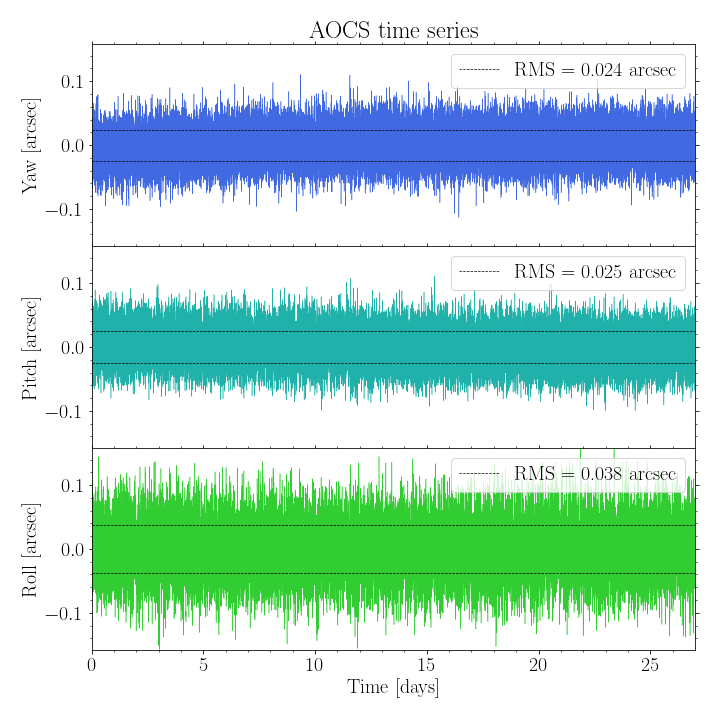

In [1131]:
# Plot
pt.plotYawPitchRollTimeSeries(t/3600., signals.T, title='AOCS time series');

In [1140]:
# Determine PSD of yaw
f, psd = periodogram(x, 8, scaling='density')
f   *= 1e6  # [muHz]
psd *= 1e6  # [arcsec^2/muHz]
psd_med = median_filter(psd, 100)

<IPython.core.display.Javascript object>


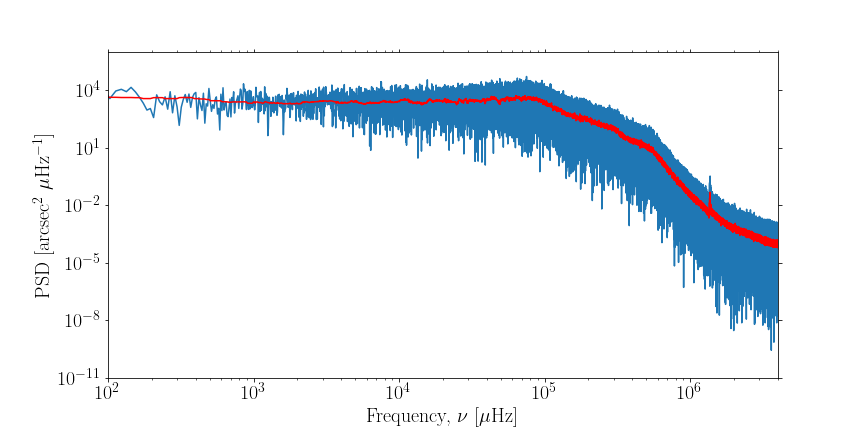

In [1143]:
# Plot PSD
plt.figure(figsize=(12,6))
plt.plot(f, psd)
plt.plot(f, psd_med, 'r-')
plt.xlabel(r"Frequency, $\nu$ [$\mu$Hz]")
plt.ylabel(r"PSD [arcsec$^2$ $\mu$Hz$^{-1}$]")
plt.xlim(1e2, f.max())
plt.ylim(1e-11, 1e6)
plt.xscale('log')
plt.yscale('log');

---
### 1.2) AOCS jitter time series from Prime 2020 January
---
We use the $8\,\rm Hz$ AOCS jitter time series simulated delivered by the ESA Prime contractor the 2021-01-09. See the technidal note: *Description of pointing data delivery as part of System PDR* (`PTO-OHB-SYS-MEM-0222 i.1.0`). This dataset consist of several simulations of which the first called `PLATO_PDR_FPM_02_longrun_APE`. 

In [1144]:
path = "/lhome/nicholas/Nextcloud/Platoman/Models/Jitter/Prime2020jan"
df = pd.read_csv(f'{path}/01_PLATO_PDR_FPM_02_longrun_APE.csv', delimiter=';', 
                 names=['t', 'x', 'y', 'z'], skiprows=[0,1])
df.head()

,t,x,y,z
0,1000.000,0.000001,9.850000e-07,2.750000e-07
1,1000.125,0.000001,9.780000e-07,2.940000e-07
2,1000.250,0.000001,9.840000e-07,3.200000e-07
3,1000.375,0.000001,9.960000e-07,3.510000e-07
4,1000.500,0.000001,1.000000e-06,3.770000e-07


In [1145]:
# Let time series start at zero seconds
df['t'] -= df['t'].iloc[0]

# Convert angles from rad -> arcsec
for n in ['x', 'y', 'z']:
    df[n] = df[n] * 206265. 
    
df.head()

,t,x,y,z
0,0.000,0.301147,0.203171,0.056723
1,0.125,0.301147,0.201727,0.060642
2,0.250,0.294959,0.202965,0.066005
3,0.375,0.286708,0.205440,0.072399
4,0.500,0.276395,0.206265,0.077762


<IPython.core.display.Javascript object>


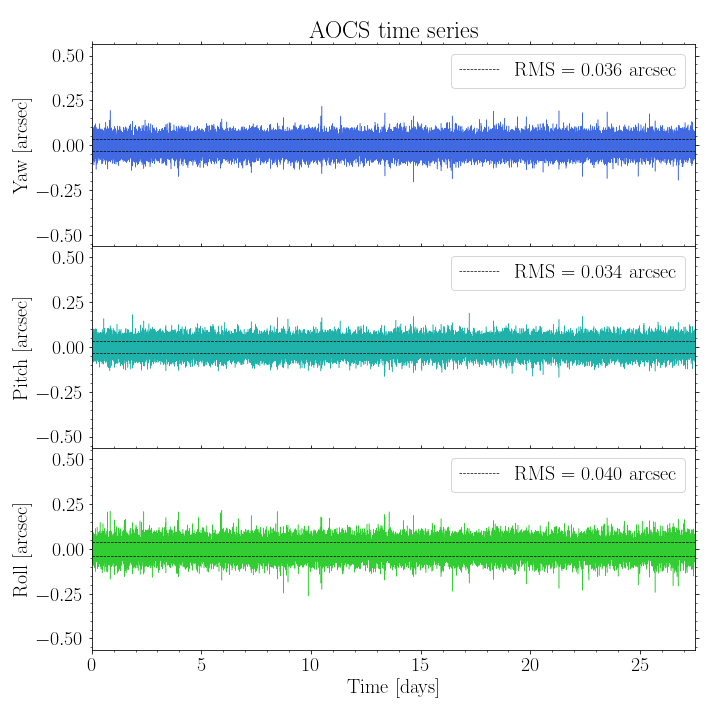

In [1146]:
# Plot jitter time series]
pt.plotYawPitchRollTimeSeries(df["t"].to_numpy()/3600., df.to_numpy()[:,1:].T, title='AOCS time series');

In [1147]:
# Determine PSD of yaw
f, psd = periodogram(df["x"], 8, scaling='density')
f   *= 1e6  # [muHz]
psd *= 1e6  # [ppm^2/muHz]
psd_med = median_filter(psd, 100)

<IPython.core.display.Javascript object>


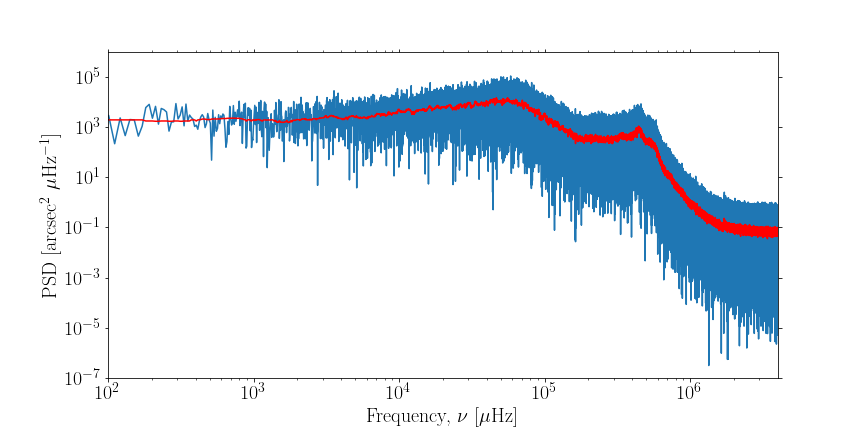

In [1148]:
# Plot PSD of yaw
plt.figure(figsize=(12,6))
plt.plot(f, psd)
plt.plot(f, psd_med, 'r-')
plt.xlabel(r"Frequency, $\nu$ [$\mu$Hz]")
plt.ylabel(r"PSD [arcsec$^2$ $\mu$Hz$^{-1}$]")
plt.xlim(1e2, f.max())
plt.ylim(1e-7, 1e6)
plt.xscale('log')
plt.yscale('log')

In [1081]:
# Split time from signals to adapt to plots below
data = df.to_numpy()
time    = data[:,0]
signals = data[:,1:]

# Save jitter file
np.savetxt(f'{workdir}/AOCS_Prime_2020jan_28h_8Hz.txt', data, delimiter=' ',
          fmt=['%.3f', '%.9f', '%.9f', '%.9f'])

---
### 1.3) Pointing Reproducibility Error (PRE)
---

In [1082]:
# Perfect pointing to provisional SPF (ICRS - equatorial)
ra  = 86.79870508
dec = -46.39594703
rot = -4.
sigma = 3
quarters = np.arange(1,9) # Q1-Q8

# Coordinates
ICRS = np.array([ra, dec, rot])

# Pointing Reproducibility Error (PRE) in P/L reference frame (yaw, pitch, roll)
t = 3.0/3600
b = 6.0/3600

# Find distribution within 3 sigma of req.
tt = np.array([np.random.normal(0, t/sigma) for i in range(len(quarters))])
bb = np.array([np.random.normal(0, b/sigma) for i in range(len(quarters))])

# Corresponding yaw, pitch, roll
y = tt
z = 3 * y
x = bb - z

# ICRS pointing angles
phi   = np.deg2rad(ra)
theta = np.deg2rad(dec)

# Find change to pointing for quarters
coor = np.zeros((len(quarters), 4))
for i in range(len(quarters)):
    data = changeOfPointing(x[i], y[i], z[i], phi, theta)[0]
    coor[i,:] = np.append(quarters[i], data)

# Save file with relative pointing errors [deg]
np.savetxt('P/lhome/nicholas/Nextcloud/Platoman/Models/TOURE.txt', coor, fmt=['%i', '%0.8f', '%0.8f', '%0.8f'])

# Print generated values
print('Yaw, Pitch, and Roll angles')
print(x)
print(y)
print(z)
print('\nChange of coordinates [arcsec]')
print(coor*3600)
print('\nNew coordinates [deg]')
for i in range(len(quarters)):
    print(coor[i][1]+ra, coor[i][2]+dec, coor[i][3])

Yaw, Pitch, and Roll angles
[ 5.41359197e-04 -1.20220034e-03  4.44324798e-04 -9.79567759e-04
 -2.45432924e-04 -8.66484899e-05 -1.31670035e-04  2.11100529e-04]
[-1.78019728e-04  2.31738683e-04 -2.96754428e-04  2.70879770e-04
  1.34233827e-04  4.02689923e-05  6.41763983e-05  8.20803219e-05]
[-0.00053406  0.00069522 -0.00089026  0.00081264  0.0004027   0.00012081
  0.00019253  0.00024624]

Change of coordinates [arcsec]
[[ 3.60000000e+03 -2.03090697e+00 -1.87114652e+00 -1.43495177e+00]
 [ 7.20000000e+03  2.64375029e+00  4.22671394e+00  3.16279288e+00]
 [ 1.08000000e+04 -3.38547105e+00 -1.46996766e+00 -1.19967806e+00]
 [ 1.44000000e+04  3.09028454e+00  3.40814256e+00  2.58902837e+00]
 [ 1.80000000e+04  1.53138317e+00  8.24934561e-01  6.58348026e-01]
 [ 2.16000000e+04  4.59401765e-01  2.94347879e-01  2.31388761e-01]
 [ 2.52000000e+04  7.32145229e-01  4.45984354e-01  3.52050078e-01]
 [ 2.88000000e+04  9.36399014e-01 -7.95808857e-01 -5.37498216e-01]]

New coordinates [deg]
86.79814093917543 -

---
### 1.4) Camera alignment errors in yaw, pitch, and roll (x, y, z)
---

In [1083]:
# Pointing Reproducibility Error (PRE) in P/L reference frame (yaw, pitch, roll)
t = 4.5/60  # [deg]
b = 9.0/60  # [deg]

# Find distribution within 3 sigma of req.
tt = np.array([np.random.normal(0, t/sigma) for i in range(24)])
bb = np.array([np.random.normal(0, b/sigma) for i in range(24)])

# Corresponding yaw, pitch, roll
dy = tt
dz = 3 * dy
dx = bb - dz
mu, sigma = 0, sigma # mean and standard deviation
s = np.random.normal(mu, sigma, 1000)
count, bins, ignored = plt.hist(s, 30, density=True)

# Plot histogram and data
plt.plot(bins, 1/(sigma * np.sqrt(2 * np.pi)) * 
         np.exp( - (bins - mu)**2 / (2 * sigma**2) ),
         linewidth=2, color='r')
plt.show()

# Save APE camera misalignments
np.savetxt('APE.txt', np.transpose([tt, bb]), fmt='%.8f')

# Print generate values
print('Alt, Az, Yaw, Pitch, and Roll alignment error for all 24 N-CAMs [arcmin]')
print(np.transpose([tt, bb, dx, dy, dz])*60)

Alt, Az, Yaw, Pitch, and Roll alignment error for all 24 N-CAMs [arcmin]
[[-0.77415793 -3.08033719 -0.7578634  -0.77415793 -2.32247379]
 [ 0.14619827  3.44219862  3.00360382  0.14619827  0.4385948 ]
 [-1.75431207  4.65982761  9.92276383 -1.75431207 -5.26293622]
 [-1.36466946 -2.88383665  1.21017174 -1.36466946 -4.09400839]
 [ 0.98992512  3.61895722  0.64918186  0.98992512  2.96977536]
 [ 0.92310455  0.86518077 -1.90413289  0.92310455  2.76931366]
 [ 1.55438267 -4.069095   -8.73224302  1.55438267  4.66314802]
 [ 0.21085321  1.56645902  0.9338994   0.21085321  0.63255962]
 [ 2.42912423  1.07399184 -6.21338085  2.42912423  7.28737269]
 [ 3.36318625  2.30041337 -7.78914538  3.36318625 10.08955875]
 [-2.6141906   5.90493079 13.74750258 -2.6141906  -7.84257179]
 [-0.04704812  3.99621108  4.13735544 -0.04704812 -0.14114437]
 [ 0.36721135 -0.40454913 -1.50618318  0.36721135  1.10163405]
 [-1.30549882  6.24914422 10.16564068 -1.30549882 -3.91649646]
 [-1.67429469  2.57065689  7.59354095 -1.6742

---

## 2) Data Analysis: Merged N-CAM LCs

---

In [1175]:
def star_info(filename):
        
    # Fetch info about target star
    cols = ["id", "ra", "dec", "x", "y", "mag", "ccd", "xccd", "yccd", "xfp", "yfp"]
    df = pd.read_csv(filename, delimiter=' ', comment='#', names=cols)

    # Fetch V magnitude
    mag = df["mag"][0]
    
    # Number of contaminants
    ncon = len(df["id"]) - 1

    # Distance from optical axis [deg]
    f = 247.52 # [mm] 
    rOA = np.rad2deg(rf.gnomonicRadialDistanceFromOpticalAxis(df["xfp"][0], df["yfp"][0], f))

    # Custom metric to measure the stellar pollution ratio
    SPR = 0
    n = len(df["mag"])
    if n >= 1:
        for k in range(1, n):
            dmag = df["mag"].diff()[k]  
            rpix = np.sqrt(df["x"].diff()[k]**2 + df["y"].diff()[k]**2)
            SPR += 1/(1+dmag+rpix)
            # If the contaminants is brighter than the target SPR becomes negative.
            # Here we are only interested in the absolute pollution:
            if SPR < 0: SPR += 1
      
    # Finito!   
    return mag, rOA, ncon, SPR

In [1176]:
def merge_cameras(inputDir, outputFile, numStar):

    # Open a pandas data frame and write to it
    df = pd.DataFrame()
    
    # Loop over star simulated

    for i in range(1, numStar+1):
        
        # Read path
        starID = f"{i}".zfill(9)
        path = f"{inputDir}/{starID}/" 

        # Load all feather files
        lc = PhotometryFile(path, mode="multi")
 
        # Unpack all zip files in the path folder
        lc.unpack()
    
        # Check if any data exist for a given star
        
        try: filename_cat = glob.glob(path + "*.cat")[0]
        except: pass
        else:
            
            # First fetch star info
            # NOTE: first files needs to be unpacked
            mag, rOA, ncon, SPR = star_info(filename_cat)

            # Loop over each quarter

            for q in range(1,9):

                # Print star processed
                print(f"Star: {i}, Quarter {q}", end="\r")

                # Merge all observations for the same quarter 
                lc_merged, ncam = lc.merge(quarter=q)
                
                # Check that any light curve exist for a given quarter
                if not ncam == 0:
                
                    # Estimate NSR
                    NSR = lc_merged.getNSR()

                    # Write data to feather
                    data = {"star":i, "mag":mag, "rOA":rOA, "quarter":q, "ncam":ncam, 
                            "ncon":ncon, "SPR":SPR, "NSR":NSR}
                    df = df.append(data, ignore_index=True)

            # Delete unpacked files again to not overflow storage memory
            for files_ftr in glob.iglob(os.path.join(path, '*.ftr')):    os.remove(files_ftr)
            for files_cat in glob.iglob(os.path.join(path, '*.cat')):    os.remove(files_cat)
            for files_inv in glob.iglob(os.path.join(path, '*.invert')): os.remove(files_inv)

    # Save final feather
    df = df.astype({"star":int, "mag":np.float32, "rOA":np.float32, "quarter":int, "ncam":int, 
                    "ncon":int, "SPR":np.float32, "NSR":np.float32})
    df.to_feather(outputFile)

---
### 2.1) No Jitter
---

In [1273]:
# User parameters
inputDirNone = "/lhome/nicholas/sims_kul21/jitterNone"
outputFileNoneMerged = os.getcwd() + "/resultsJitterNoneMerged.ftr"
numStar = 400
# merge_cameras(inputDirNone, outputFileNoneMerged, numStar)

In [1275]:
# Load results and sort logically
df1 = pd.read_feather(outputFileNoneMerged)
df1 = df1.sort_values(by=["star", "quarter"])
df1_single = df1.loc[df1["ncon"] == 0]
df1.head()

,star,mag,rOA,quarter,ncam,ncon,SPR,NSR
0,1,9.64,12.722017,1,12,1,0.158036,32.761650
1,1,9.64,12.722017,2,6,1,0.158036,47.075985
2,1,9.64,12.722017,3,11,1,0.158036,33.800575
3,1,9.64,12.722017,4,6,1,0.158036,46.278606
4,1,9.64,12.722017,5,11,1,0.158036,34.048370


<IPython.core.display.Javascript object>


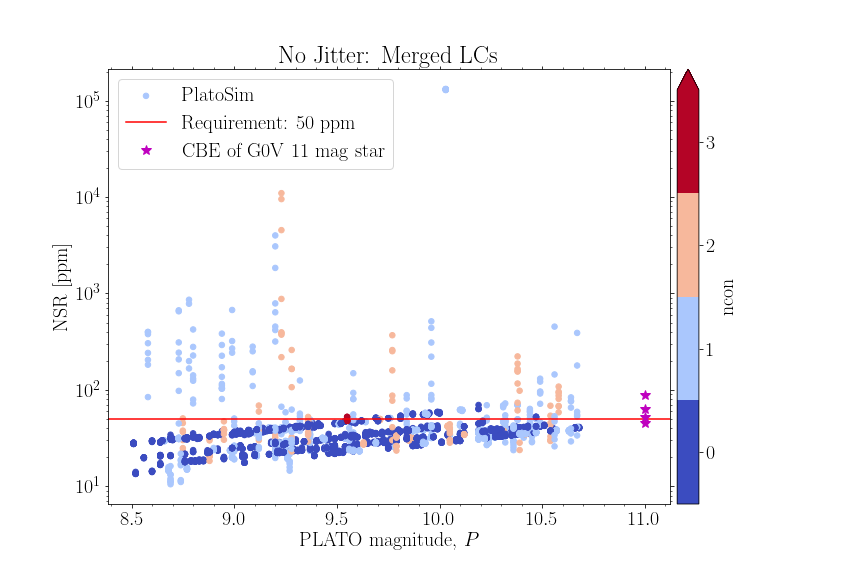

In [1276]:
# Fetch only the first star and the first quarter
fig, ax = pt.plotNSRvsMagnitude(df1, column="ncon", cmap="coolwarm")
ax.set_title("No Jitter: Merged LCs")
ax.plot([11, 11, 11, 11], [88, 63, 52, 45], 'm*', ms=10, label="CBE of G0V 11 mag star")
ax.legend(loc="best");

<IPython.core.display.Javascript object>


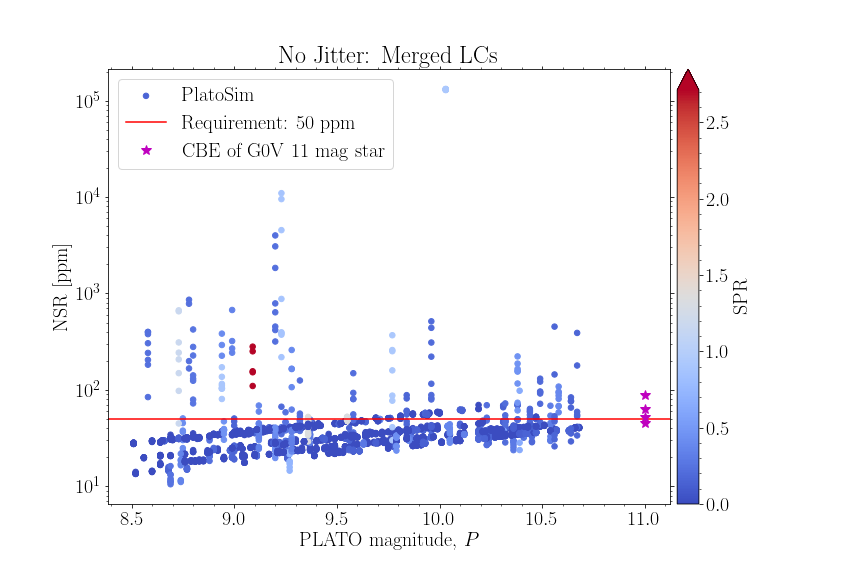

In [1277]:
# Fetch only the first star and the first quarter
fig, ax = pt.plotNSRvsMagnitude(df1, column="SPR", cmap="coolwarm")
ax.set_title("No Jitter: Merged LCs")
ax.plot([11, 11, 11, 11], [88, 63, 52, 45], 'm*', ms=10, label="CBE of G0V 11 mag star")
ax.legend(loc="best");

<IPython.core.display.Javascript object>


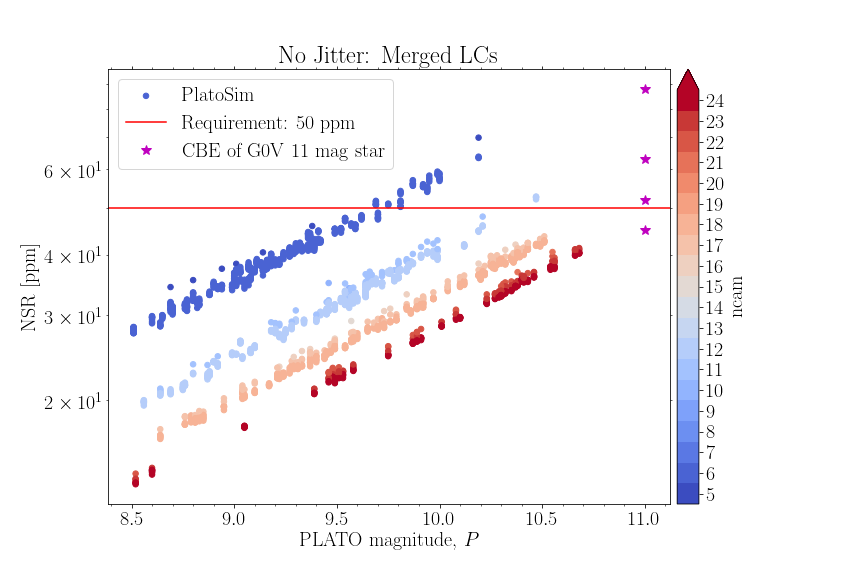

In [1278]:
# # Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df1_single, column="ncam", cmap="coolwarm")
ax.set_title("No Jitter: Merged LCs")
ax.plot([11, 11, 11, 11], [88, 63, 52, 45], 'm*', ms=10, label="CBE of G0V 11 mag star")
ax.legend();

---
### 2.2) Red Noise
---

In [1279]:
# User parameters
inputDirRed = "/lhome/nicholas/sims_kul21/jitterRed"
outputFileRedMerged = os.getcwd() + "/resultsJitterRedMerged.ftr"
numStar = 400
# merge_cameras(inputDirRed, outputFileRedMerged, numStar)

In [1280]:
# Load results and sort logically
df2 = pd.read_feather(outputFileRedMerged)
df2 = df2.sort_values(by=["star", "quarter"])
df2_single = df2.loc[df2["ncon"] == 0]
df2.head()

,star,mag,rOA,quarter,ncam,ncon,SPR,NSR
0,1,9.64,12.928117,1,17,1,0.156194,27.512461
1,1,9.64,12.928117,2,6,1,0.156194,47.168289
2,1,9.64,12.928117,3,18,1,0.156194,27.068834
3,1,9.64,12.928117,4,6,1,0.156194,46.532719
4,1,9.64,12.928117,5,18,1,0.156194,26.841160


<IPython.core.display.Javascript object>


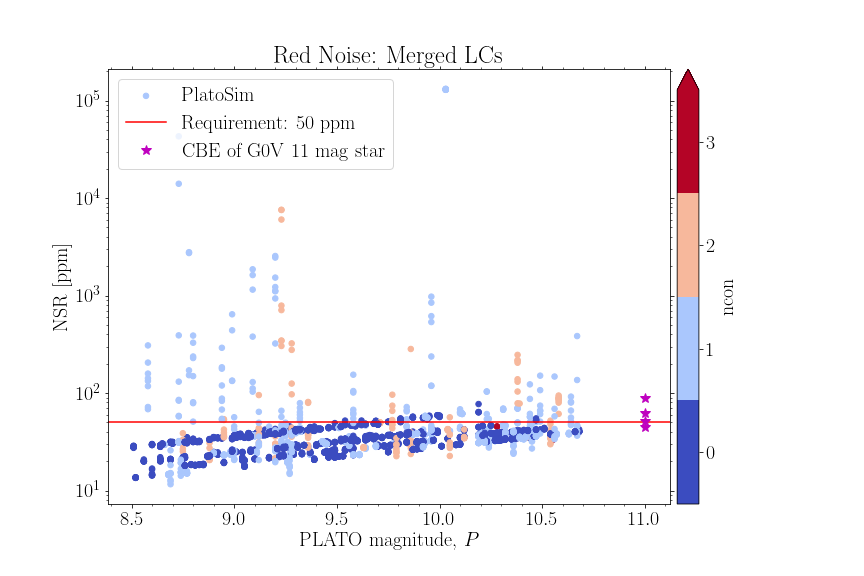

In [1281]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df2, column="ncon", cmap="coolwarm")
ax.set_title("Red Noise: Merged LCs")
ax.plot([11, 11, 11, 11], [88, 63, 52, 45], 'm*', ms=10, label="CBE of G0V 11 mag star")
ax.legend();

<IPython.core.display.Javascript object>


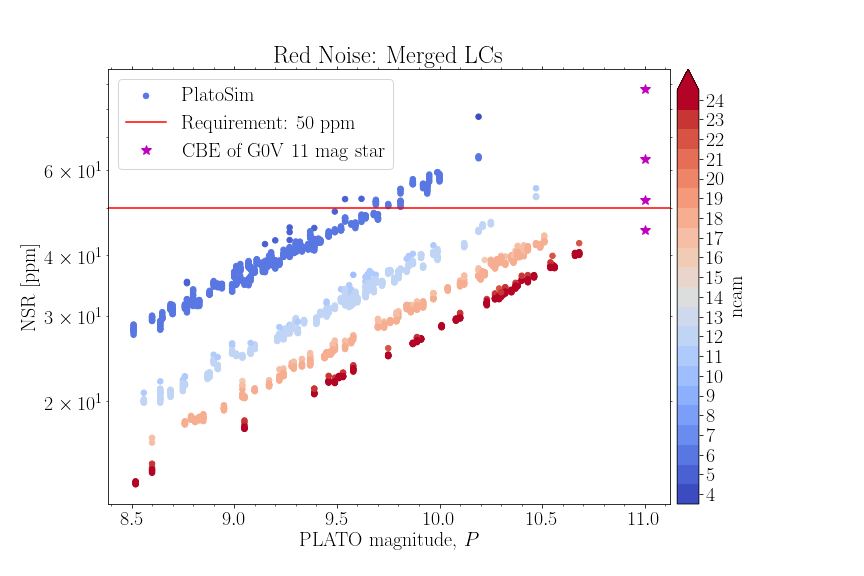

In [1282]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df2_single, column="ncam", cmap="coolwarm")
ax.set_title("Red Noise: Merged LCs")
ax.plot([11, 11, 11, 11], [88, 63, 52, 45], 'm*', ms=10, label="CBE of G0V 11 mag star")
ax.legend();

---
### Prime Jitter
---

In [1283]:
# User parameters
inputDirPrime = "/lhome/nicholas/sims_kul21/jitterPrime"
outputFilePrimeMerged = os.getcwd() + "/resultsJitterPrimeMerged.ftr"
numStar = 400
# merge_cameras(inputDirPrime, outputFilePrimeMerged, numStar)

In [1284]:
# Load results and sort logically
df3 = pd.read_feather(outputFilePrimeMerged)
df3 = df3.sort_values(by=["star", "quarter"])
df3_single = df3.loc[df3["ncon"] == 0]
df3.head()

,star,mag,rOA,quarter,ncam,ncon,SPR,NSR
0,1,9.64,12.924238,4,6,1,0.15622,46.677635
1,1,9.64,12.924238,5,12,1,0.15622,32.378193
2,1,9.64,12.924238,8,6,1,0.15622,46.619282
3,2,8.92,16.511221,5,6,0,0.00000,34.878002
4,3,9.10,10.498152,2,6,0,0.00000,35.850555


<IPython.core.display.Javascript object>


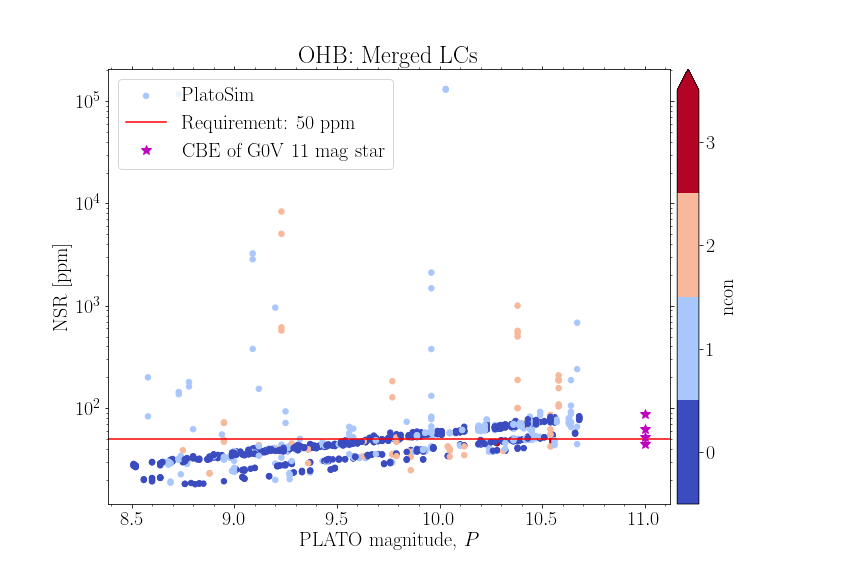

In [1285]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df3, column="ncon", cmap="coolwarm")
ax.set_title("OHB: Merged LCs")
ax.plot([11, 11, 11, 11], [88, 63, 52, 45], 'm*', ms=10, label="CBE of G0V 11 mag star")
ax.legend();

<IPython.core.display.Javascript object>


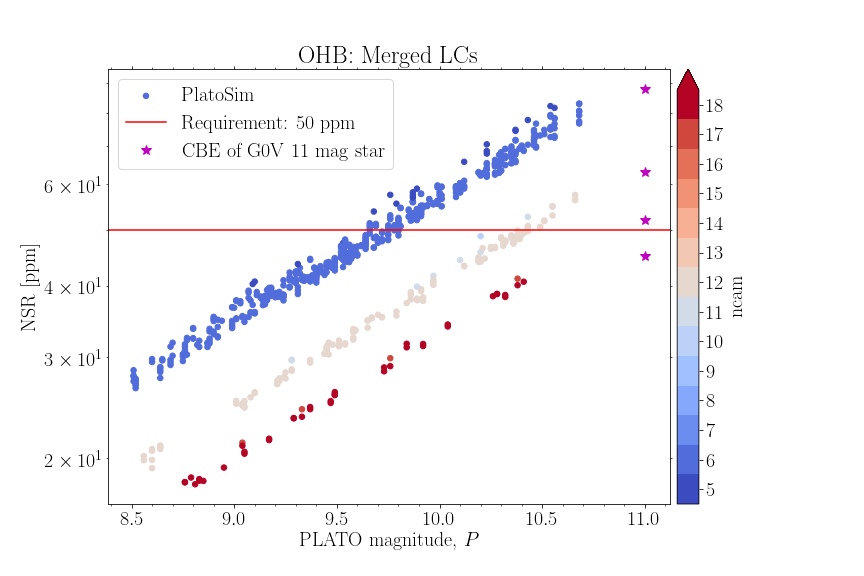

In [1286]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df3_single, column="ncam", cmap="coolwarm")
ax.set_title("OHB: Merged LCs")
ax.plot([11, 11, 11, 11], [88, 63, 52, 45], 'm*', ms=10, label="CBE of G0V 11 mag star")
ax.legend();

---
### Resdiuals and trends
---

In [1287]:
# Copy data frames
df21 = df1.copy()
df31 = df2.copy()
df32 = df3.copy()
df21_single = df1_single.copy()
df31_single = df2_single.copy()
df32_single = df3_single.copy()

# Create column to plot the residuals
df21["res"] = df2["NSR"] - df1["NSR"]
df31["res"] = df3["NSR"] - df1["NSR"]
df32["res"] = df3["NSR"] - df2["NSR"]

# Residuals without for single stars
df21_single["res"] = df2_single["NSR"] - df1_single["NSR"]
df31_single["res"] = df3_single["NSR"] - df1_single["NSR"]
df32_single["res"] = df3_single["NSR"] - df2_single["NSR"]

<IPython.core.display.Javascript object>


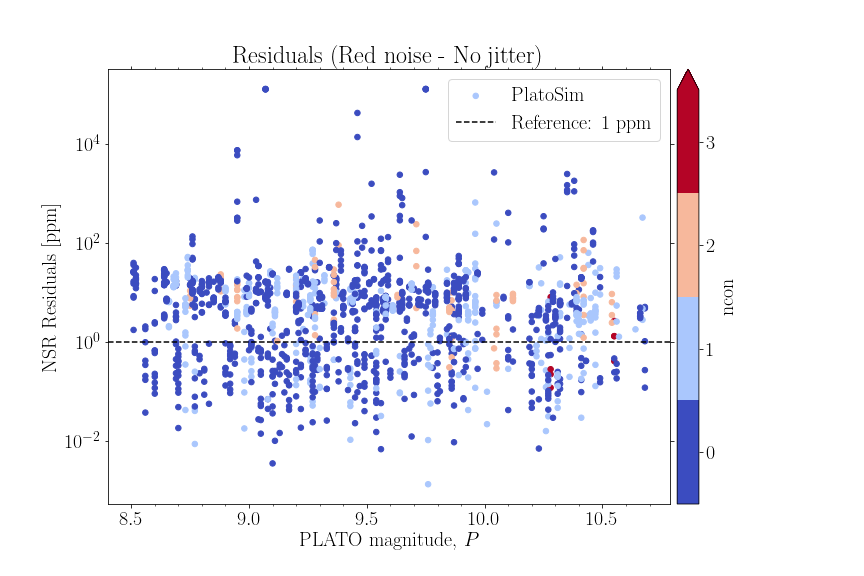

In [1288]:
# Plot residuals
fig, ax = pt.plotNSRvsMagnitude(df21, column="ncon", residuals=True, cmap="coolwarm")
ax.set_title("Residuals (Red noise - No jitter)");

<IPython.core.display.Javascript object>


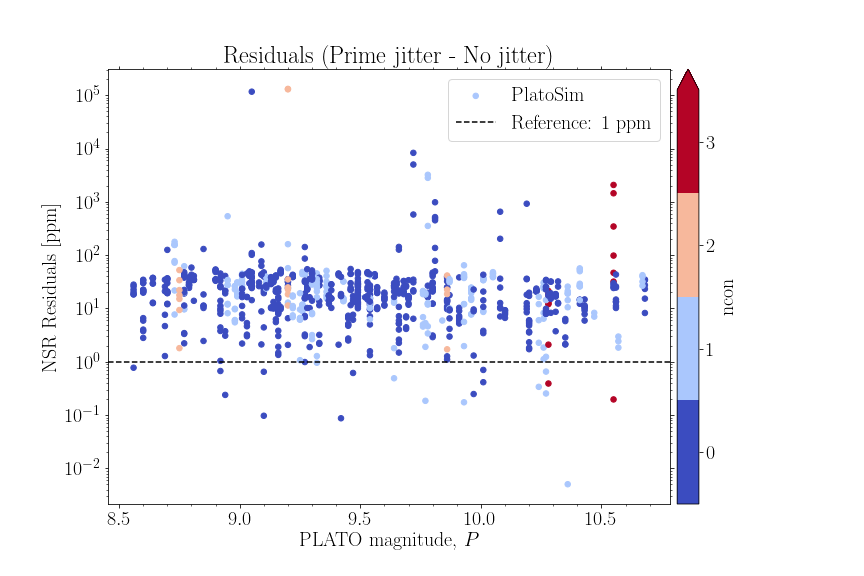

In [1289]:
# Plot residuals
fig, ax = pt.plotNSRvsMagnitude(df31, column="ncon", residuals=True, cmap="coolwarm")
ax.set_title("Residuals (Prime jitter - No jitter)");

<IPython.core.display.Javascript object>


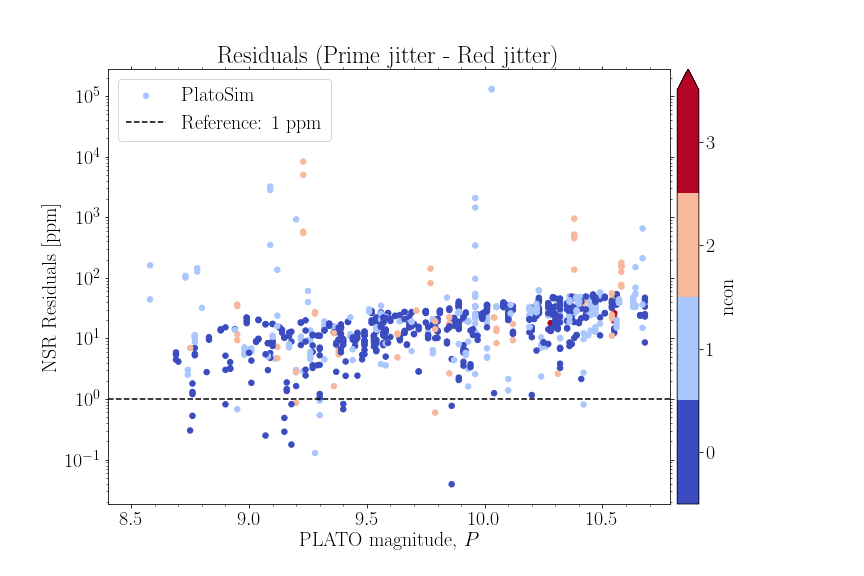

In [1294]:
# Plot residuals
fig, ax = pt.plotNSRvsMagnitude(df32, column="ncon", residuals=True, cmap="coolwarm")
ax.set_title("Residuals (Prime jitter - Red jitter)");

<IPython.core.display.Javascript object>


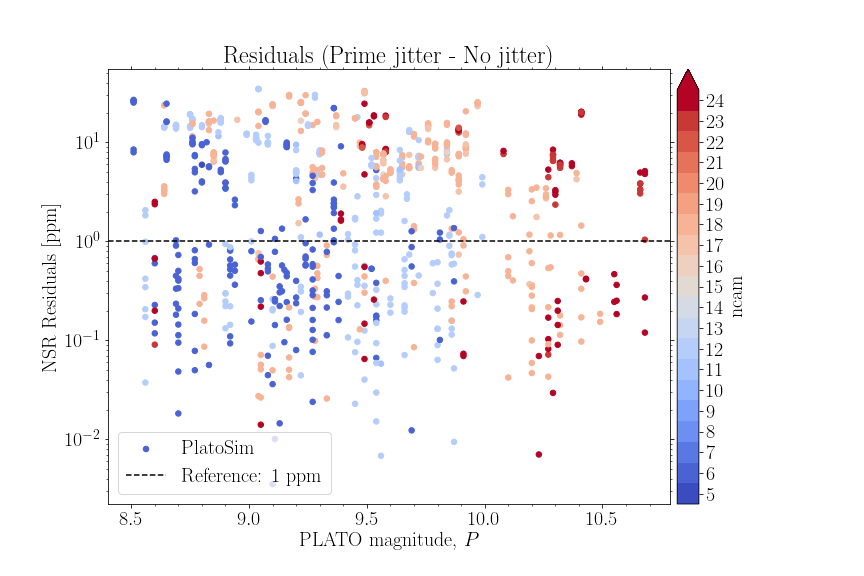

In [1295]:
# Plot residuals
fig, ax = pt.plotNSRvsMagnitude(df21_single, column="ncam", residuals=True, cmap="coolwarm")
ax.set_title("Residuals (Red jitter - No jitter)");

<IPython.core.display.Javascript object>


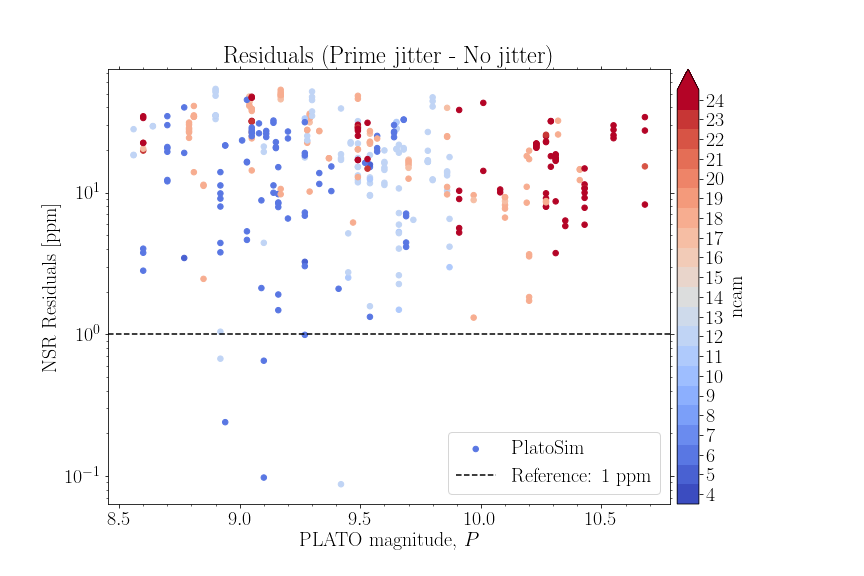

In [1296]:
# Plot residuals
fig, ax = pt.plotNSRvsMagnitude(df31_single, column="ncam", residuals=True, cmap="coolwarm")
ax.set_title("Residuals (Prime jitter - No jitter)");

<IPython.core.display.Javascript object>


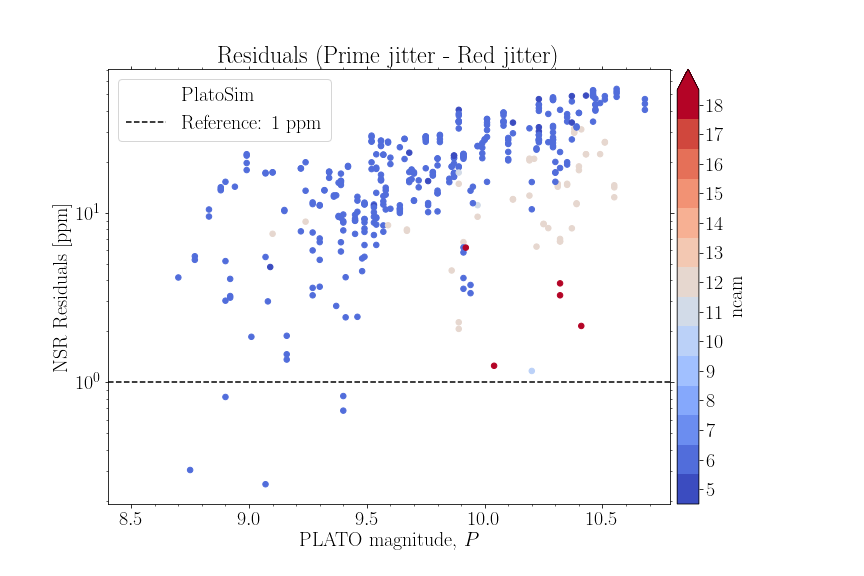

In [1297]:
# Plot residuals
fig, ax = pt.plotNSRvsMagnitude(df32_single, column="ncam", residuals=True, cmap="coolwarm")
ax.set_title("Residuals (Prime jitter - Red jitter)");

---
## 3) Data Analysis: Indiviual N-CAM LCs
---

In [1097]:
def analyse(inputDir, outputFile, numStar):

    # Open a pandas data frame and write to it
    df = pd.DataFrame()
    cols = ["id", "ra", "dec", "x", "y", "mag", "ccd", "xccd", "yccd", "xfp", "yfp"]
    f = 247.52 # [mm] 
    
    # Loop over star simulated

    for i in range(1, numStar+1):

        # Print star processed
        print(i, end="\r")

        # Read path
        starIDfolder = f"{i}".zfill(9)
        path = f"{inputDir}/{starIDfolder}/" 

        # Fetch all zip files
        files = glob.glob(path+ "*.zip")
        numFiles = len(files)
 
        # Loop over each group/cam/quarter simulation

        for j in range(numFiles):

            # Unpack zip files
            with ZipFile(files[j], "r") as unzip:
                unzip.extractall(path)

            # Get file names
            filename_ftr = files[j][:-3] + "ftr"
            filename_cat = files[j][:-3] + "cat"
            filename_inv = files[j][:-3] + "invert"    

            # Fetch light curve object
            try: lc = PhotometryFile(filename_ftr)
            except: pass
            else:

                # Fetch NSR from RMS [ppm/sqrt(h)]
                NSR = lc.getNSR()
                
                # Fetch info about observation
                group, camera, quarter = lc.obs()

                # Fetch info about target star
                dc = pd.read_csv(filename_cat, delimiter=' ', comment='#', names=cols)

                # Fetch V magnitude
                mag = dc["mag"][0]

                # Distance from optical axis [deg]
                rOA = np.rad2deg(rf.gnomonicRadialDistanceFromOpticalAxis(dc["xfp"][0], dc["yfp"][0], f))

                # Intra-pixel position
                xcen = dc["x"][0] - 3.5
                ycen = dc["y"][0] - 3.5
                rCP = np.sqrt(xcen**2 + ycen**2)

                # Mean centroid error in percent
                xcen     = lc.xcen()
                ycen     = lc.ycen()
                xcen_err = lc.xcen_err()
                ycen_err = lc.ycen_err()
                rcen     = np.sqrt(xcen**2 + ycen**2)
                rcen_err = np.sqrt(xcen_err**2 + ycen_err**2)
                rcen_err_mean = rcen_err.mean() / rcen.mean() * 100
                if rcen_err_mean > 100: rcen_err_mean = 100

                # Mean flux error in percent
                flux     = np.abs(lc.flux())
                flux_err = np.abs(lc.flux_err())
                flux_err_mean = flux_err.mean() / flux.mean() * 100                
                if flux_err_mean > 100: flux_err_mean = 100

                # Custom metric to measure the stellar pollution ratio
                SPR = 0
                n = len(dc["mag"])
                if n >= 1:
                    for k in range(1, n):
                        dmag = dc["mag"].diff()[k]  
                        rpix = np.sqrt(dc["x"].diff()[k]**2 + dc["y"].diff()[k]**2)
                        SPR += 1/(1+dmag+rpix)
                        # If the contaminants is brighter than the target SPR becomes negative.
                        # Here we are only interested in the absolute pollution:
                        if SPR < 0: SPR += 1

                # Write data to feather
                data = {"star":i, "group":group, "camera":camera, "quarter":quarter, "mag":mag, "rOA":rOA, "rCP":rCP, 
                        "ferr":flux_err_mean, "rerr":rcen_err_mean, "SPR":SPR, "NSR":NSR}
                df = df.append(data, ignore_index=True)

                # Delete unpacked files again to not overflow storage memory
                os.remove(filename_ftr)
                os.remove(filename_cat)
                os.remove(filename_inv)

    # Save final feather
    df = df.astype({"star":int, "group":int, "camera":int, "quarter":int, "rOA":np.float32, "rCP":np.float32, 
                    "ferr":np.float32, "rerr":np.float32, "SPR":np.float32, "NSR":np.float32})
    df.to_feather(outputFile)

---
### 3.1) No jitter
---

In [1098]:
# User parameters
inputDirNone   = "/lhome/nicholas/sims_kul21/jitterNone"
outputFileNone = os.getcwd() + "/resultsJitterNone.ftr"
numStar = 400
# analyse(inputDirNone, outputFileNone, numStar)

In [1099]:
# Load results and sort logically
df1 = pd.read_feather(outputFileNone)
df1 = df1.sort_values(by=["star", "group", "camera", "quarter"]) 
df1_single = df1.loc[df1["SPR"] == 0]
df1.head()

,star,group,camera,quarter,mag,rOA,rCP,flux_err_mean,rcen_err_mean,SPR,NSR
43,1,1,1,1,9.64,0.874822,0.363688,0.134320,0.025297,0.159877,111.320984
5,1,1,1,2,9.64,12.722816,0.450936,0.141503,0.030517,0.158036,115.473663
11,1,1,1,5,9.64,0.875279,0.317007,0.135542,0.024922,0.159877,109.739059
8,1,1,1,6,9.64,12.722017,0.318834,0.142698,0.030190,0.158036,115.752892
30,1,1,2,1,9.64,0.874822,0.363688,0.134242,0.025257,0.159877,111.461617


<IPython.core.display.Javascript object>


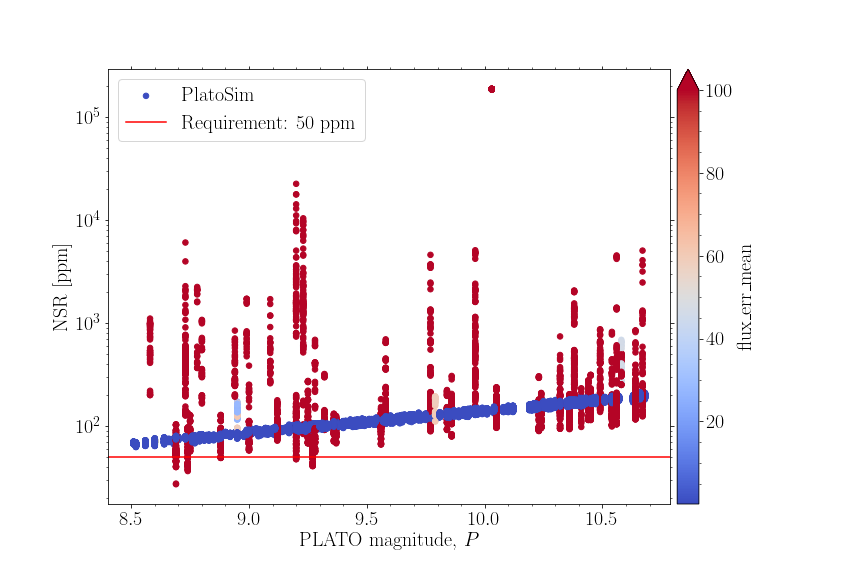

In [1100]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df1, column="flux_err_mean", cmap="coolwarm")
ax.set_title("");

<IPython.core.display.Javascript object>


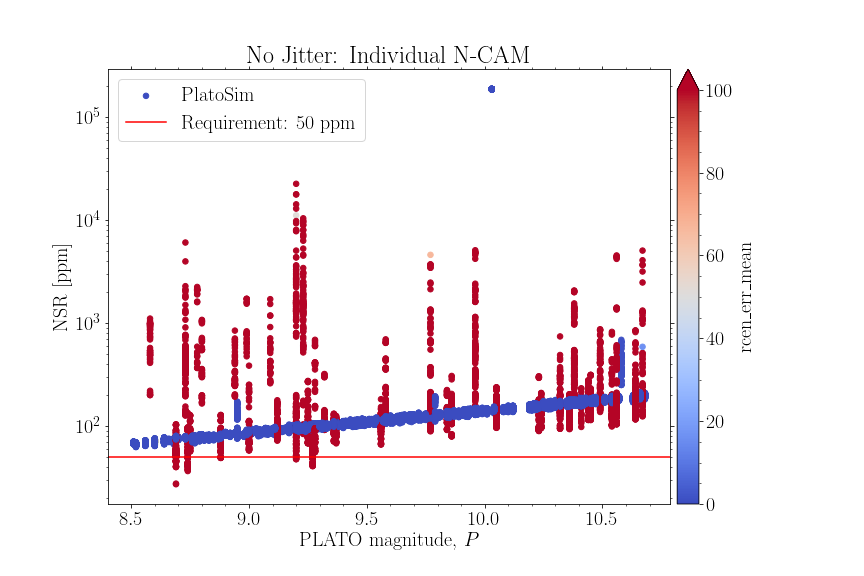

In [1101]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df1, column="rcen_err_mean", cmap="coolwarm")
ax.set_title("No Jitter: Individual N-CAM");

<IPython.core.display.Javascript object>


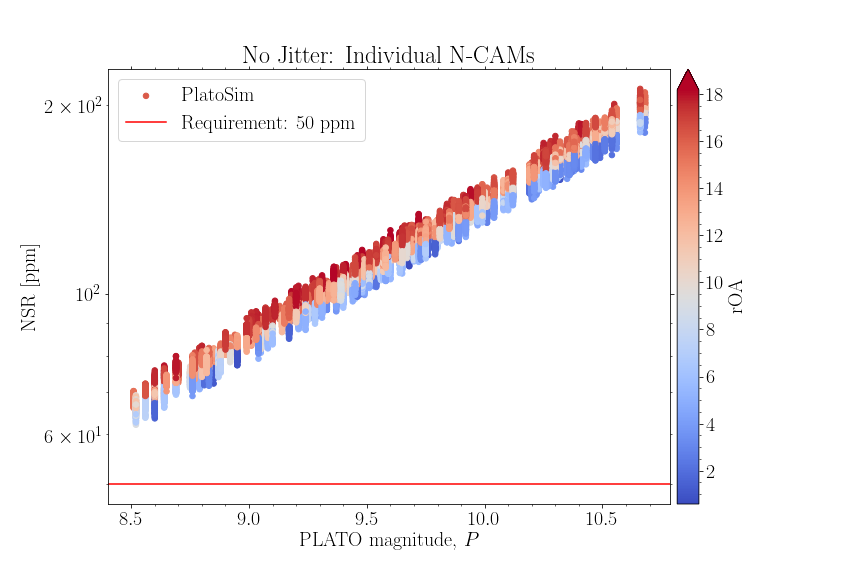

In [1102]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df1_single, column="rOA", cmap="coolwarm")
ax.set_title("No Jitter: Individual N-CAMs");

<IPython.core.display.Javascript object>


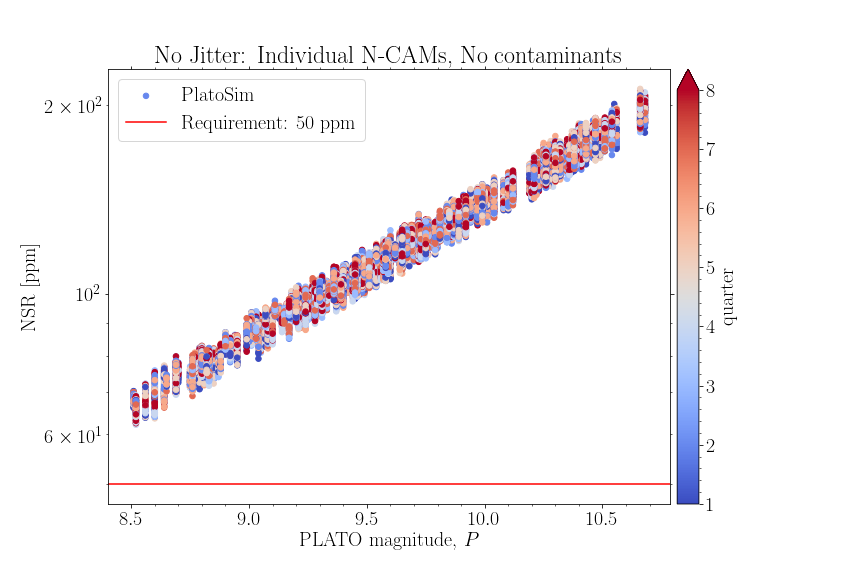

In [1103]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df1_single, column="quarter", cmap="coolwarm")
ax.set_title("No Jitter: Individual N-CAMs, No contaminants");

### 2.2.2) No Jitter: Only 1 quarter

In [1104]:
# Show only quarter
# df1_oneq = df1_nocon.loc[df1_nocon["quarter"] == 8]
# fig, ax = pt.plotNSRvsMagnitude(df1_oneq, column="rOA", cmap="coolwarm", figsize=(14,10))
# ax.set_title("Single N-CAM measurements, No contaminants");

---
### 3.2) Red Noise
---

In [1105]:
# User parameters
inputDirRed   = "/lhome/nicholas/sims_kul21/jitterRed"
outputFileRed = os.getcwd() + "/resultsJitterRed.ftr"
numStar = 400
# analyse(inputDirRed, outputFileRed, numStar)

In [1106]:
# Load results and sort logically
df2 = pd.read_feather(outputFileRed)
df2 = df2.sort_values(by=["star", "group", "camera", "quarter"])
df2_single = df2.loc[df2["SPR"] == 0]
df2.head()

,star,group,camera,quarter,mag,rOA,rCP,flux_err_mean,rcen_err_mean,SPR,NSR
59,1,1,1,1,9.64,0.874888,0.337975,0.134424,0.025656,0.159872,109.919342
9,1,1,1,2,9.64,12.928955,0.381632,0.139313,0.029948,0.156193,117.187866
17,1,1,1,5,9.64,0.875345,0.330153,0.135596,0.025306,0.159872,108.773491
13,1,1,1,6,9.64,12.928117,0.292817,0.140679,0.029967,0.156194,117.983231
40,1,1,2,1,9.64,0.874888,0.337975,0.134297,0.025553,0.159872,107.102600


<IPython.core.display.Javascript object>


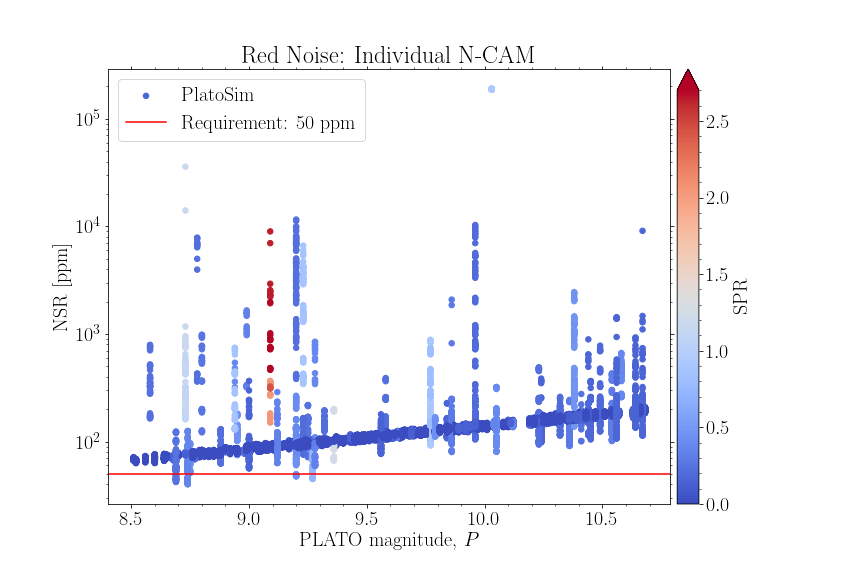

In [1107]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df2, column="SPR", cmap="coolwarm")
ax.set_title("Red Noise: Individual N-CAM");

<IPython.core.display.Javascript object>


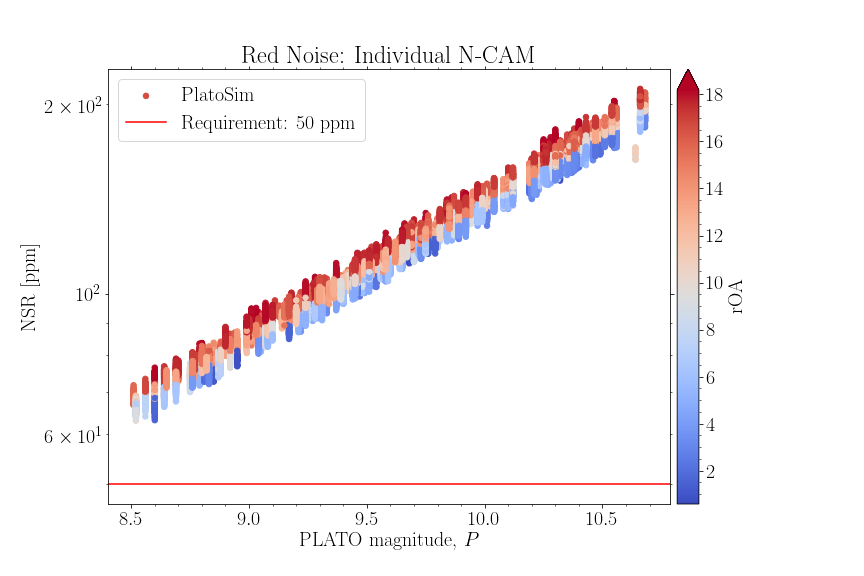

In [1108]:
fig, ax = pt.plotNSRvsMagnitude(df2_single, column="rOA", cmap="coolwarm")
ax.set_title("Red Noise: Individual N-CAM");

In [1109]:
df2["res"] = df2["NSR"] - df1["NSR"]
df2_single["res"] = df2_single["NSR"] - df1_single["NSR"]

/tmp/ipykernel_2087513/2539106638.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_single["res"] = df2_single["NSR"] - df1_single["NSR"]


<IPython.core.display.Javascript object>


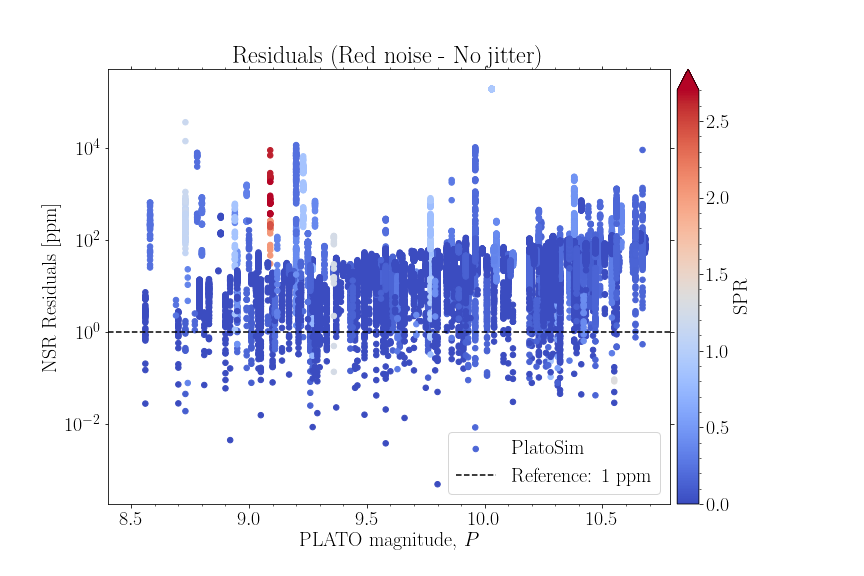

In [1110]:
# Plot residuals
fig, ax = pt.plotNSRvsMagnitude(df2, column="SPR", residuals=True)
ax.set_title("Residuals (Red noise - No jitter)");

<IPython.core.display.Javascript object>


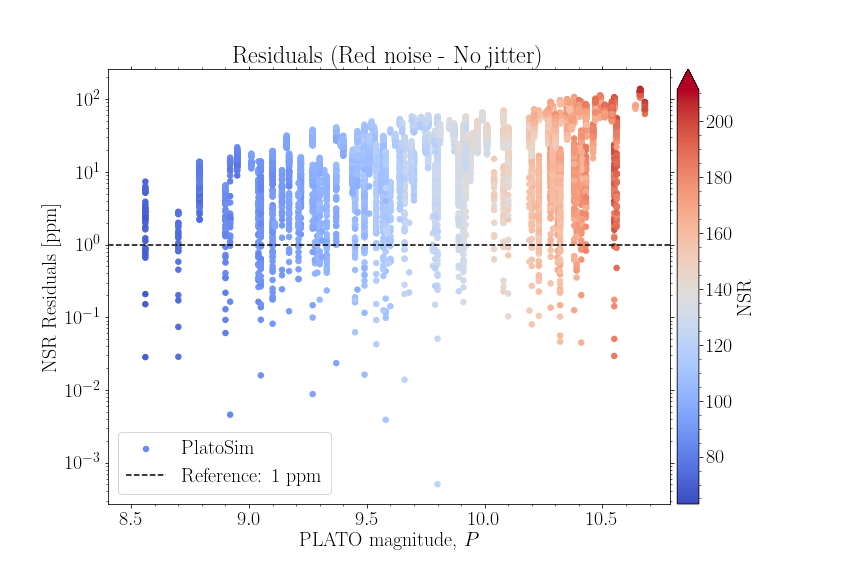

In [1111]:
# Plot residuals
fig, ax = pt.plotNSRvsMagnitude(df2_single, column="NSR", residuals=True)
ax.set_title("Residuals (Red noise - No jitter)");

In [1112]:
# df = df1.loc[df1["quarter"] == 1]

# for i in range(numStar):
#     ncam = len(df.loc[abs(df1["star"] == i)])
#     df["NSR_ncam"] = df["NSR"] / np.sqrt(ncam)

# df["NSR"] = []  

In [1113]:
# df["NSR"] = [df["NSR"].iloc[i]/np.sqrt(len(df.iloc[i])) for i in range 